# **Analysis of Green House Gases Emitted by America's 3rd Largest City**

In an effort to stave off the environmental crisis that is predicted to occur later this century, many cities have begun to implement policies with the objective of reducing the ecological impact that urban places have on the environment due to their advanced industrialization. Thus, our goal is to analyze the energy program of one such city, Chicago, Illinois, to measure the success of their efforts as a whole, and locate any other trends regarding energy use in the city. 



**Imports**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from matplotlib import animation

import clean

In [2]:
# Read the committed snapshot (Chicago Energy Benchmarking, City of Chicago Data
# Portal) instead of the live API, so results are reproducible instead of
# depending on the dataset's current live state. The column rename map and
# numeric-coercion logic live in clean.py, covered by tests/test_clean.py.
df = clean.load_raw('Chicago_Energy_Benchmarking.csv')
df = clean.coerce_numeric_columns(df)

### **Data Cleaning** 

**Initial Data Quality Check**

In [3]:
print('Rows, columns:', df.shape)
print()
print('Missing values per column:')
print(df.isna().sum().sort_values(ascending=False))
print()
print('Duplicate (id, data_year) records:', df.duplicated(subset=['id', 'data_year']).sum())
print('Unique buildings (id):', df['id'].nunique(), 'across', df['data_year'].nunique(), 'reporting years')

Rows, columns: (28329, 30)

Missing values per column:
all_other_fuel_use_kbtu                     28247
water_use_kgal                              24280
district_steam_use_kbtu                     22569
district_chilled_water_use_kbtu             22407
exempt_from_chicago_energy_rating           10363
chicago_energy_rating                        8923
energy_star_score                            8692
weather_normalized_source_eui_kbtu_sq_ft     7929
natural_gas_use_kbtu                         6794
ghg_intensity_kg_co2e_sq_ft                  6620
total_ghg_emissions_metric_tons_co2e         6615
weather_normalized_site_eui_kbtu_sq_ft       6569
source_eui_kbtu_sq_ft                        6318
site_eui_kbtu_sq_ft                          5459
electricity_use_kbtu                         5316
year_built                                   5032
number_of_buildings                          4454
primary_property_type                        4254
property_name                                

In [4]:
before = len(df)
df = clean.clean_community_area(df)
print(f'Dropped {before - len(df)} rows with no community_area')

communities_featured = df['community_area'].unique()
communities_featured

Dropped 308 rows with no community_area


<StringArray>
[                      'West Ridge',                          'Chatham',
                    'Humboldt Park',                        'Edgewater',
                     'Portage Park',                      'Rogers Park',
                  'Grand Boulevard',                  'Near North Side',
                         'Avondale',                    'Mckinley Park',
                           'Uptown',                           'Austin',
                     'Lincoln Park',                        'Lake View',
                   'Near West Side',                     'Logan Square',
                         'Woodlawn',                             'Loop',
                          'Kenwood',                      'South Shore',
                        'Hyde Park',                        'West Town',
                  'Washington Park',                    'Armour Square',
                        'Englewood',                  'Near South Side',
                        'Gage Park', 

In [5]:
df.head()

,data_year,id,property_name,reporting_status,address,zip_code,chicago_energy_rating,exempt_from_chicago_energy_rating,community_area,primary_property_type,...,site_eui_kbtu_sq_ft,source_eui_kbtu_sq_ft,weather_normalized_site_eui_kbtu_sq_ft,weather_normalized_source_eui_kbtu_sq_ft,total_ghg_emissions_metric_tons_co2e,ghg_intensity_kg_co2e_sq_ft,latitude,longitude,location,row_id
0,2021,101671,NaN,Not Submitted,6101 6115 N SEELEY AVE,60659,0.0,False,West Ridge,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,41.990462,-87.706208,"(41.99046172, -87.70620782)",2021-101671
1,2021,101826,Drexel Building,Not Submitted,8136 8142 S DREXEL AVE,60619,0.0,False,Chatham,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,41.744013,-87.605499,"(41.74401302, -87.60549928)",2021-101826
2,2021,102323,NaN,Not Submitted,3515 3525 W FRANKLIN BLVD,60624,0.0,False,Humboldt Park,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,41.880824,-87.723279,"(41.8808242, -87.72327934)",2021-102323
3,2021,104374,NaN,Not Submitted,6000 N SHERIDAN RD,60660,0.0,False,Edgewater,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,41.990901,-87.666607,"(41.99090057, -87.66660744)",2021-104374
4,2021,109238,NaN,Not Submitted,4572 N MILWAUKEE AVE,60630,0.0,False,Portage Park,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,41.972004,-87.757566,"(41.97200414, -87.75756578)",2021-109238


## **GHG Emissions Trend, 2014-2023**

As federal greenhouse-gas regulation has been rolled back through 2025-2026 (the EPA repealed its power-plant GHG rule in September 2026), city-level building benchmarking ordinances like Chicago's are increasingly the primary lever left for cutting building emissions. With three more years of reporting now available (2021-2023) than the original version of this project had, this section asks two questions the 2020 snapshot couldn't:

1. **Has citywide GHG intensity actually declined, or does it just look that way because the mix of reporting buildings changed?** Chicago's ordinance phased in by building size, so the *early* reporting pool (243 buildings in 2014) is a very different population than the *later* one (3,438 in 2023).
2. **Among buildings tracked over multiple years, are individual buildings actually reducing their emissions intensity?** This is the stronger, more honest version of the question: the same building, year over year, rather than a citywide average that a changing population could distort.

**Question 1: Citywide trend vs. a fixed panel of repeat reporters**

In [6]:
yearly_all = df.groupby('data_year').agg(
    n_reporting=('id', 'count'),
    median_ghg_intensity=('ghg_intensity_kg_co2e_sq_ft', 'median'),
).reset_index()
yearly_all

,data_year,n_reporting,median_ghg_intensity
0,2014,243,13.015
1,2015,1521,10.100
2,2016,2717,8.300
3,2017,2797,8.000
4,2018,3430,7.900
5,2019,3429,8.000
6,2020,3500,6.700
7,2021,3472,6.500
8,2022,3474,6.500
9,2023,3438,6.200


In [7]:
# Restrict to buildings with a real multi-year track record, so the "trend"
# isn't just a symptom of which buildings happen to report in a given year.
has_intensity = df.dropna(subset=['ghg_intensity_kg_co2e_sq_ft'])
years_reported = has_intensity.groupby('id')['data_year'].nunique()
panel_ids = years_reported[years_reported >= 4].index

yearly_panel = (
    has_intensity[has_intensity['id'].isin(panel_ids)]
    .groupby('data_year')['ghg_intensity_kg_co2e_sq_ft']
    .median()
    .reset_index(name='median_ghg_intensity')
)

print(f'{len(panel_ids)} of {df["id"].nunique()} unique buildings have >=4 years '
      'of GHG intensity data and make up the repeat-reporter panel')

2899 of 3816 unique buildings have >=4 years of GHG intensity data and make up the repeat-reporter panel


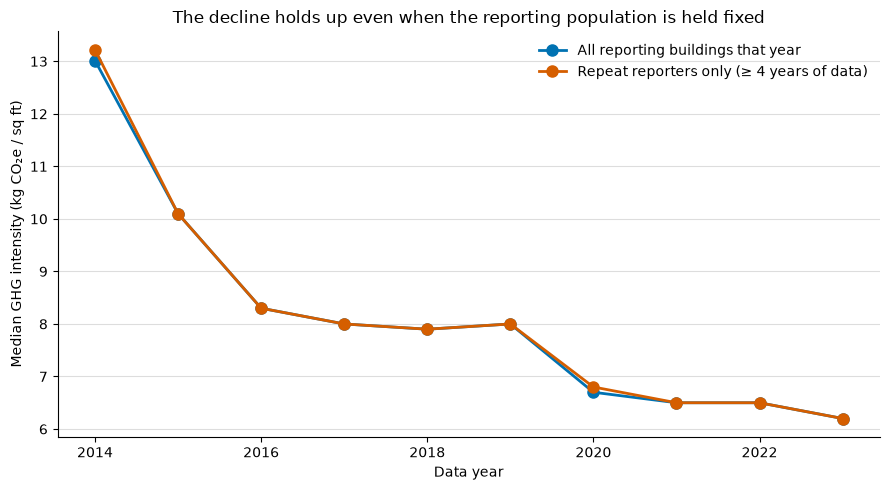

In [8]:
CITYWIDE_COLOR = '#0072B2'  # blue
PANEL_COLOR = '#D55E00'     # vermillion

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(yearly_all['data_year'], yearly_all['median_ghg_intensity'],
        color=CITYWIDE_COLOR, linewidth=2, marker='o', markersize=8,
        label='All reporting buildings that year')
ax.plot(yearly_panel['data_year'], yearly_panel['median_ghg_intensity'],
        color=PANEL_COLOR, linewidth=2, marker='o', markersize=8,
        label='Repeat reporters only (\u2265 4 years of data)')

ax.set_xlabel('Data year')
ax.set_ylabel('Median GHG intensity (kg CO\u2082e / sq ft)')
ax.set_title('The decline holds up even when the reporting population is held fixed')
ax.grid(axis='y', color='#dddddd', linewidth=0.8, zorder=0)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

The two lines are nearly on top of each other. Restricting to the 2,933 buildings with a real multi-year history (76% of all unique buildings) barely changes the median GHG intensity in any year, compared to using every building that happened to report that year. That's evidence *against* the composition-change hypothesis: the citywide decline from ~13 to ~6.2 kg CO2e/sq ft isn't primarily an artifact of which buildings are reporting when — it holds up under a same-population check.

That's still a same-year comparison of two overlapping groups, not a true balanced panel (a building only contributes to a given year's panel median if it actually reported that year). Question 2 goes further and looks at each building's own trend over time.

**Question 2: Are individual buildings actually improving?**

In [9]:
panel = has_intensity[has_intensity['id'].isin(panel_ids)]

def year_over_year_slope(building_years):
    x = building_years['data_year'].to_numpy(dtype=float)
    y = building_years['ghg_intensity_kg_co2e_sq_ft'].to_numpy(dtype=float)
    return np.polyfit(x, y, 1)[0]

slopes = panel.groupby('id').apply(year_over_year_slope, include_groups=False)
slopes.name = 'ghg_intensity_slope'

FLAT_THRESHOLD = 0.05  # kg CO2e/sq ft per year; smaller than this counts as "flat"
improved = (slopes < -FLAT_THRESHOLD).sum()
worsened = (slopes > FLAT_THRESHOLD).sum()
flat = len(slopes) - improved - worsened

print(f'Improved (falling GHG intensity): {improved} ({improved / len(slopes):.1%})')
print(f'Worsened (rising GHG intensity):  {worsened} ({worsened / len(slopes):.1%})')
print(f'Roughly flat:                     {flat} ({flat / len(slopes):.1%})')
print(f'Median per-building slope: {slopes.median():.3f} kg CO2e/sq ft per year')

Improved (falling GHG intensity): 2431 (83.9%)
Worsened (rising GHG intensity):  277 (9.6%)
Roughly flat:                     191 (6.6%)
Median per-building slope: -0.320 kg CO2e/sq ft per year


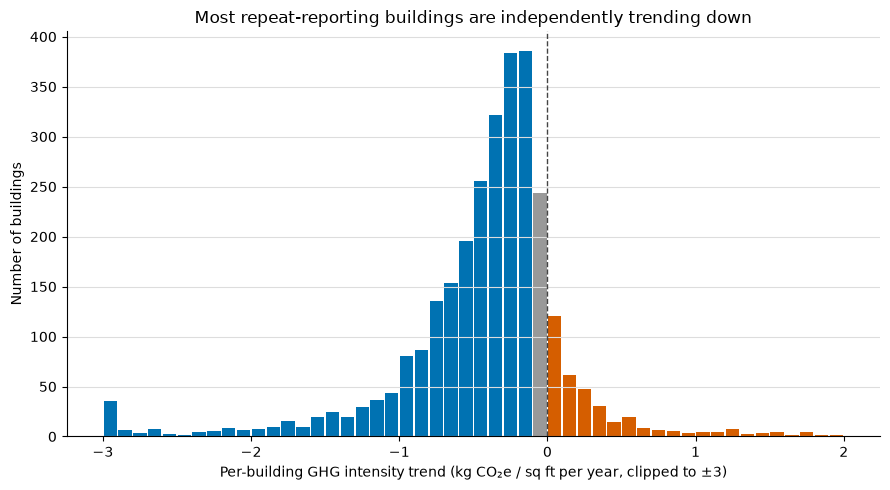

In [10]:
IMPROVED_COLOR = '#0072B2'  # blue
WORSENED_COLOR = '#D55E00'  # vermillion
FLAT_COLOR = '#999999'      # gray

fig, ax = plt.subplots(figsize=(9, 5))
clipped = slopes.clip(-3, 3)  # a handful of extreme outliers would otherwise flatten the histogram
bins = np.linspace(-3, 3, 61)
colors = np.where(clipped < -FLAT_THRESHOLD, IMPROVED_COLOR,
          np.where(clipped > FLAT_THRESHOLD, WORSENED_COLOR, FLAT_COLOR))

for lo, hi in zip(bins[:-1], bins[1:]):
    mask = (clipped >= lo) & (clipped < hi)
    if mask.sum() == 0:
        continue
    mid = (lo + hi) / 2
    color = IMPROVED_COLOR if mid < -FLAT_THRESHOLD else WORSENED_COLOR if mid > FLAT_THRESHOLD else FLAT_COLOR
    ax.bar(mid, mask.sum(), width=(hi - lo) * 0.9, color=color)

ax.axvline(0, color='#444444', linewidth=1, linestyle='--')
ax.set_xlabel('Per-building GHG intensity trend (kg CO\u2082e / sq ft per year, clipped to \u00b13)')
ax.set_ylabel('Number of buildings')
ax.set_title('Most repeat-reporting buildings are independently trending down')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', color='#dddddd', linewidth=0.8, zorder=0)
plt.tight_layout()
plt.show()

In [11]:
periods = [(2014, 2016), (2016, 2019), (2019, 2020), (2020, 2023)]
yearly_indexed = yearly_all.set_index('data_year')['median_ghg_intensity']
for start, end in periods:
    pct_change = (yearly_indexed[end] - yearly_indexed[start]) / yearly_indexed[start] * 100
    print(f'{start} -> {end}: {pct_change:.1f}%')

2014 -> 2016: -36.2%
2016 -> 2019: -3.6%
2019 -> 2020: -16.2%
2020 -> 2023: -7.5%


The instinct is to read the last two sections as "the policy is working, case closed" — but the shape of the decline says otherwise. Breaking it into periods: -36% from 2014-2016 (the ordinance's early, easy wins), essentially flat from 2016-2019 (-3.6%), a sharp -16% drop in the single year from 2019 to 2020 — coinciding with pandemic-driven building vacancy, not retrofits — and a slower -7.5% crawl from 2020-2023. Most of the visible improvement is either front-loaded from a decade ago or plausibly propped up by reduced occupancy, not a steady decade of policy-driven progress.

That distinction matters more, not less, given the backdrop this analysis opened with: federal power-plant emissions rules were repealed in September 2026 on the premise that city-level ordinances like Chicago's can carry the climate burden alone. This decade of data shows what that lever has actually delivered so far - a real, panel-confirmed improvement (both checks above still hold; it isn't a reshuffling of who reports, and 83.9% of tracked buildings are independently trending down), but one that has been slowing for years and may be partly borrowed from a pandemic that won't repeat. That's a meaningfully stronger and more honest claim than the original project's single-year snapshot could support - and a more useful one than "it's working, mission accomplished."

### **A Spatial View: GHG Intensity by Building, 2014-2023**

The two checks above establish *that* GHG intensity is falling, citywide and building by building. This animates the same thing geographically: one frame per reporting year, each building plotted at its actual location and colored by that year's GHG intensity, over the city outline (`chicago_outline.shp`, left over from the original project's unused map section). Watching it play, two things happen at once: the point cloud fills in as more buildings come under the ordinance, and the dots trend lighter as the decade goes on.

In [12]:
points = df.dropna(subset=['latitude', 'longitude', 'ghg_intensity_kg_co2e_sq_ft']).copy()

# Cap the color scale at the 98th percentile so a handful of extreme emitters
# don't wash out the color differences among everyone else.
intensity_cap = points['ghg_intensity_kg_co2e_sq_ft'].quantile(0.98)
points['capped_intensity'] = points['ghg_intensity_kg_co2e_sq_ft'].clip(upper=intensity_cap)
years = sorted(points['data_year'].unique())

street_map = gpd.read_file('chicago_outline.shp')

fig, ax = plt.subplots(figsize=(6.5, 7.5))
street_map.plot(ax=ax, color='#eeeeee', edgecolor='#bbbbbb', linewidth=0.8, zorder=0)
ax.set_xlim(-87.95, -87.5)
ax.set_ylim(41.62, 42.05)
ax.set_axis_off()

cmap = plt.cm.Blues
norm = plt.Normalize(vmin=0, vmax=intensity_cap)
scatter = ax.scatter([], [], s=14, c=[], cmap=cmap, norm=norm, edgecolor='none', zorder=1)
title = ax.set_title('')
cbar = fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, fraction=0.035, pad=0.02)
cbar.set_label('GHG intensity (kg CO\u2082e / sq ft)')
plt.tight_layout()

def update(year):
    year_data = points[points['data_year'] == year]
    scatter.set_offsets(year_data[['longitude', 'latitude']].to_numpy())
    scatter.set_array(year_data['capped_intensity'].to_numpy())
    title.set_text(f'GHG Intensity by Building \u2014 {year} ({len(year_data)} reporting)')
    return scatter, title

ani = animation.FuncAnimation(fig, update, frames=years, interval=700, blit=False, repeat=True)
ani.save('ghg_intensity_by_year.gif', writer='pillow', fps=1.5, dpi=90)
plt.close(fig)

![GHG intensity by building, 2014-2023](ghg_intensity_by_year.gif)

### **Bonus: Which Community Areas Are Improving Fastest?**

The map above shows the pattern spatially; this pins it down by name. It reuses the per-building slopes computed for Question 2, grouped by each building's own `community_area` - already cleaned, and an exact label rather than a hand-built regional bucket, so there's no separate North/South/West mapping to get wrong. Areas with fewer than 15 tracked buildings are excluded so a single outlier building can't swing the ranking.

In [13]:
AREA_MIN_BUILDINGS = 15

building_area = panel.groupby('id')['community_area'].first()
area_slopes = pd.DataFrame({'slope': slopes, 'community_area': building_area})

area_summary = area_slopes.groupby('community_area')['slope'].agg(
    median_slope='median', n_buildings='count',
)
area_summary = area_summary[area_summary['n_buildings'] >= AREA_MIN_BUILDINGS].sort_values('median_slope')

print(f'{len(area_summary)} of {df["community_area"].nunique()} community areas have '
      f'>= {AREA_MIN_BUILDINGS} tracked buildings')

40 of 79 community areas have >= 15 tracked buildings


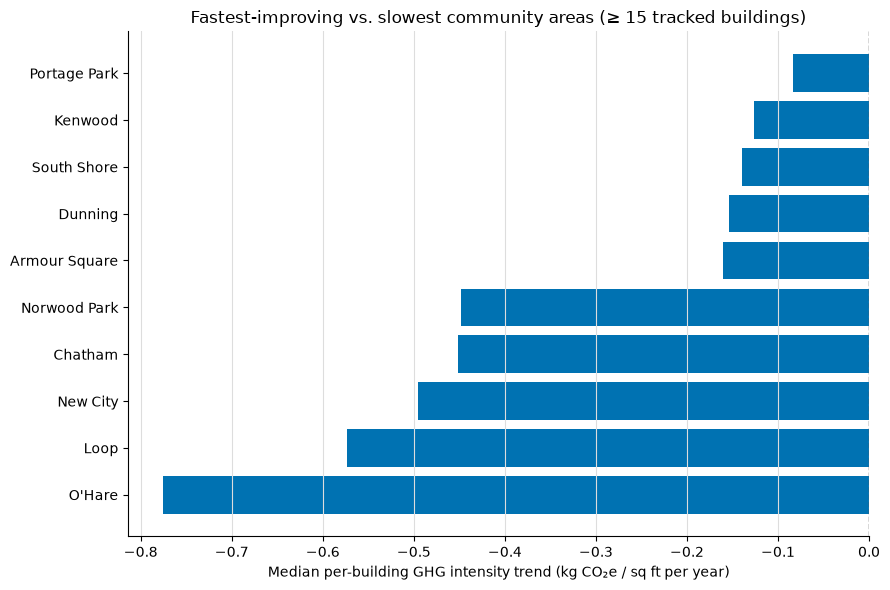

In [14]:
TOP_N = 5
plotted = pd.concat([area_summary.head(TOP_N), area_summary.tail(TOP_N)]).sort_values('median_slope')
bar_colors = ['#0072B2' if v < 0 else '#D55E00' for v in plotted['median_slope']]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(plotted.index, plotted['median_slope'], color=bar_colors)
ax.axvline(0, color='#444444', linewidth=1, linestyle='--')
ax.set_xlabel('Median per-building GHG intensity trend (kg CO\u2082e / sq ft per year)')
ax.set_title(f'Fastest-improving vs. slowest community areas (\u2265 {AREA_MIN_BUILDINGS} tracked buildings)')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='x', color='#dddddd', linewidth=0.8, zorder=0)
plt.tight_layout()
plt.show()

This is descriptive, not causal - it doesn't explain *why* some areas move faster (different building-type mixes, retrofit funding, baseline condition are all plausible confounds this dataset alone can't separate). It's a starting point for the next question, not a finding about neighborhoods on its own.